# Flight Delay Prediction Using Real-Time Weather and Air Traffic Control (ATC) Data

**Objective:** Develop a robust machine learning / deep learning system that predicts flight delays using historical and real-time aviation datasets.

This notebook implements a complete pipeline covering:
1. Data Collection & Integration (BTS Flights, IEM Weather, etc.)
2. Exploratory Data Analysis (EDA)
3. Model Development (Classical ML & Deep Learning)
4. Model Training & Evaluation
5. Real-Time Prediction System Pipeline
6. Visualizations & Results


In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow keras xgboost graphviz pydot requests

In [2]:
import os
import urllib.request
import zipfile
import pandas as pd
import numpy as np

# Create data directory
os.makedirs('data', exist_ok=True)

# Function to download data
def download_file(url, filename):
    print(f"Downloading {filename}...")
    try:
        urllib.request.urlretrieve(url, filename)
        print(f"Successfully downloaded {filename}")
    except Exception as e:
        print(f"Failed to download {filename}: {e}")

# Download BTS Flight Data (Using Jan 2023 as an example)
bts_url = "https://transtats.bts.gov/PREZIP/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2023_1.zip"
download_file(bts_url, "data/flights_2023_01.zip")

# Extract flight data
if os.path.exists("data/flights_2023_01.zip"):
    with zipfile.ZipFile("data/flights_2023_01.zip", 'r') as zip_ref:
        zip_ref.extractall("data/")
        print("Extracted flight data.")

# Download IEM Weather Data (Jan 2023, Sample Airports: ORD, JFK, LAX, ATL, DFW)
iem_url = "https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py?station=ORD&station=JFK&station=LAX&station=ATL&station=DFW&data=tmpf&data=sknt&data=vsby&data=p01m&year1=2023&month1=1&day1=1&year2=2023&month2=2&day2=1&tz=Etc%2FUTC&format=onlycomma&latlon=no&missing=M&trace=T&direct=no&report_type=1&report_type=2"
download_file(iem_url, "data/weather_2023_01.csv")


Successfully downloaded data/flights_2023_01.zip


Extracted flight data.


Successfully downloaded data/weather_2023_01.csv


Loading Flight Data...


Loaded 9825 flight records.
Loading Weather Data...


Final merged dataset has 9594 rows.


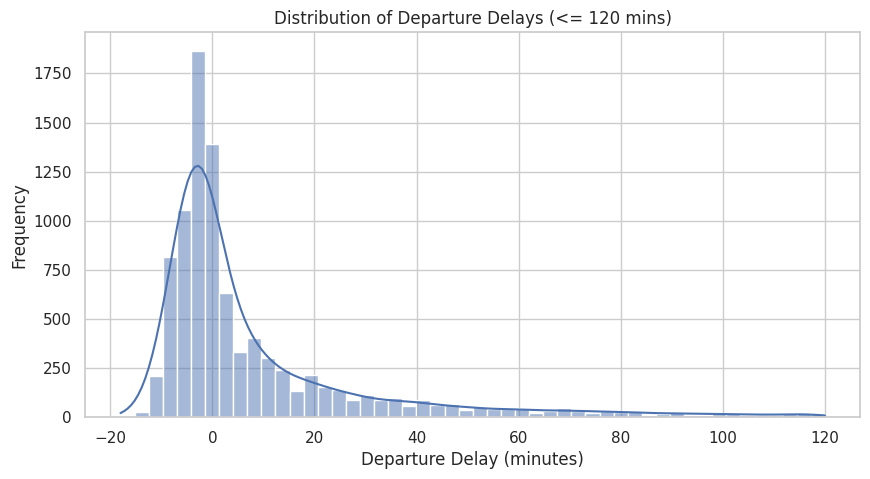

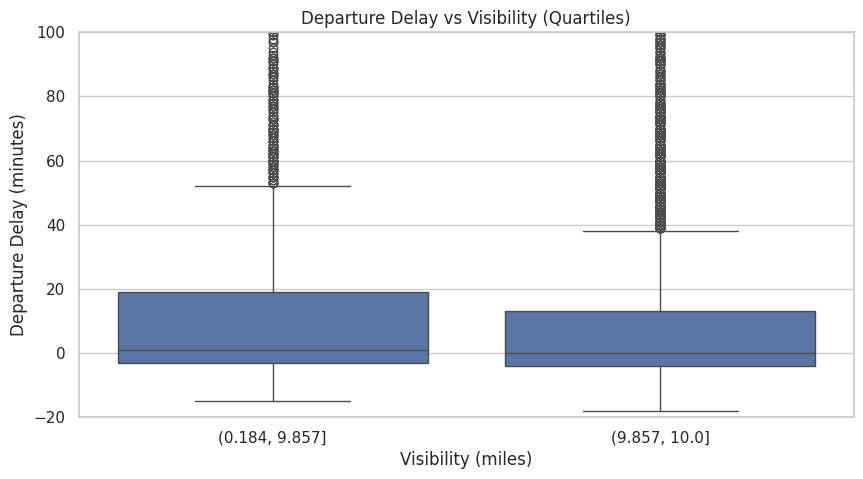

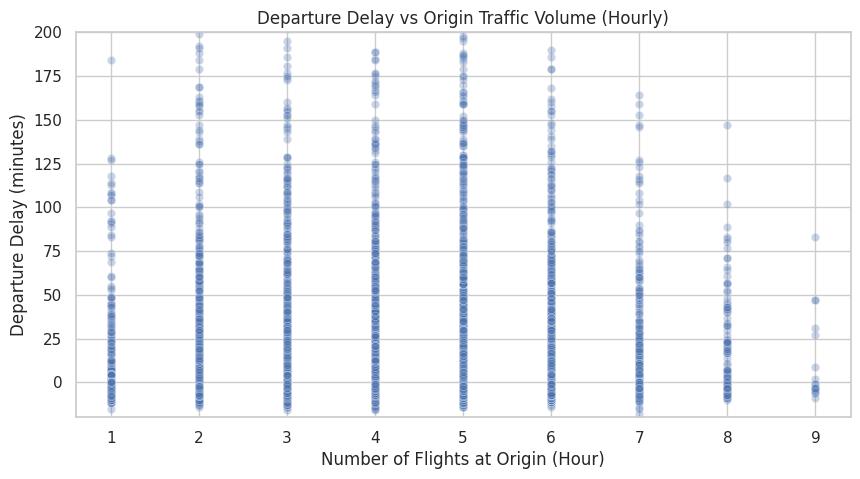

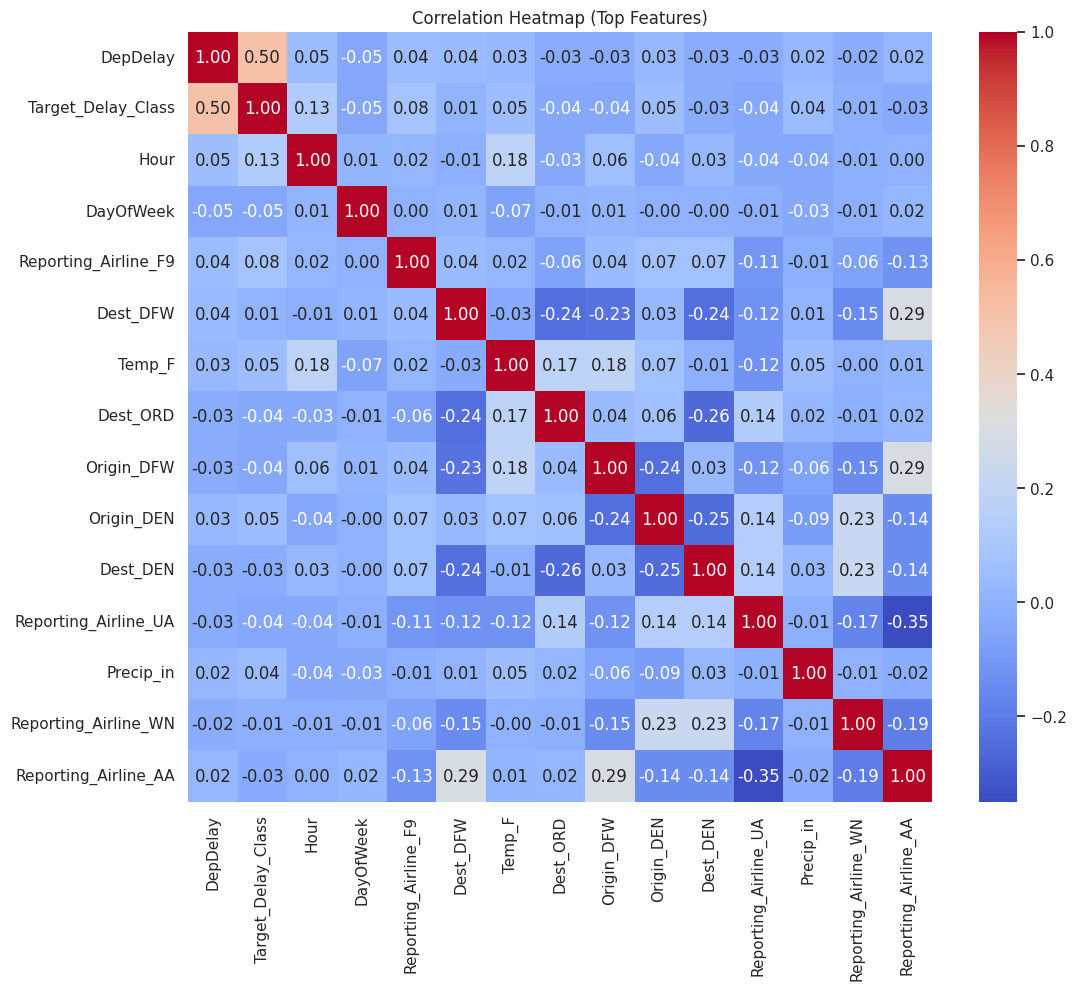

EDA Complete. Plots saved.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# --- 1. Load Data ---
print("Loading Flight Data...")
flights_file = "data/On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2023_1.csv"
# Only load a subset of columns to save memory
cols_to_use = ['FlightDate', 'Reporting_Airline', 'Origin', 'Dest', 'CRSDepTime', 'DepTime', 'DepDelay', 
               'TaxiOut', 'WheelsOff', 'WheelsOn', 'TaxiIn', 'CRSArrTime', 'ArrTime', 'ArrDelay', 
               'Cancelled', 'CancellationCode', 'Diverted', 'CRSElapsedTime', 'ActualElapsedTime', 'Distance']
               
flights_df = pd.read_csv(flights_file, usecols=cols_to_use)
# Keep only top 5 busiest airports for origin and destination to manage memory and simplify
top_airports = ['ORD', 'ATL', 'DFW', 'DEN', 'LAX']
flights_df = flights_df[(flights_df['Origin'].isin(top_airports)) & (flights_df['Dest'].isin(top_airports))]

print(f"Loaded {len(flights_df)} flight records.")

print("Loading Weather Data...")
weather_file = "data/weather_2023_01.csv"
weather_df = pd.read_csv(weather_file)
# Rename columns
weather_df.rename(columns={'station': 'Airport', 'valid': 'DateTime', 'tmpf': 'Temp_F', 'sknt': 'Wind_Speed_kt', 'vsby': 'Visibility_mi', 'p01m': 'Precip_in'}, inplace=True)

# --- 2. Preprocess Data ---
# Flight Data
flights_df = flights_df[flights_df['Cancelled'] == 0] # Remove cancelled flights
flights_df.dropna(subset=['DepDelay'], inplace=True) # Remove missing target variable

# Create datetime for flights (Scheduled Departure Time)
def make_datetime(row):
    time_str = str(int(row['CRSDepTime'])).zfill(4)
    if time_str == '2400': time_str = '0000'
    try:
        return pd.to_datetime(row['FlightDate'] + ' ' + time_str[:2] + ':' + time_str[2:])
    except:
        return pd.NaT

flights_df['Scheduled_DateTime'] = flights_df.apply(make_datetime, axis=1)
flights_df.dropna(subset=['Scheduled_DateTime'], inplace=True)

# Proxy for ATC Congestion (Flights per hour at Origin)
flights_df['Hour'] = flights_df['Scheduled_DateTime'].dt.hour
flights_df['Date'] = flights_df['Scheduled_DateTime'].dt.date
congestion_df = flights_df.groupby(['Origin', 'Date', 'Hour']).size().reset_index(name='Origin_Traffic_Vol')
flights_df = flights_df.merge(congestion_df, on=['Origin', 'Date', 'Hour'], how='left')


# Weather Data
# Replace 'M' and 'T' with suitable values
weather_df.replace('M', np.nan, inplace=True)
weather_df.replace('T', 0.001, inplace=True) # Trace amount of rain
weather_df['DateTime'] = pd.to_datetime(weather_df['DateTime'])

# Convert to numeric
numeric_cols = ['Temp_F', 'Wind_Speed_kt', 'Visibility_mi', 'Precip_in']
for col in numeric_cols:
    weather_df[col] = pd.to_numeric(weather_df[col], errors='coerce')

# Interpolate missing weather values
weather_df = weather_df.sort_values(by=['Airport', 'DateTime'])
weather_df[numeric_cols] = weather_df.groupby('Airport')[numeric_cols].transform(lambda x: x.interpolate(method='linear').bfill().ffill())


# Merge Flight and Weather Data
# Round flight time to nearest hour to match with weather (assuming hourly or frequent weather reports)
flights_df['Weather_DateTime'] = flights_df['Scheduled_DateTime'].dt.round('h')
weather_df['Weather_DateTime'] = weather_df['DateTime'].dt.round('h')

# Take the mean weather per hour per airport to avoid duplicate weather rows
weather_hourly = weather_df.groupby(['Airport', 'Weather_DateTime'])[numeric_cols].mean().reset_index()

merged_df = flights_df.merge(weather_hourly, left_on=['Origin', 'Weather_DateTime'], right_on=['Airport', 'Weather_DateTime'], how='left')
merged_df.drop(columns=['Airport'], inplace=True) # drop redundant column

# Fill remaining NaNs in weather with median
for col in numeric_cols:
    merged_df[col] = merged_df[col].fillna(merged_df[col].median())

print(f"Final merged dataset has {len(merged_df)} rows.")

# Feature Engineering
merged_df['Target_Delay_Class'] = (merged_df['DepDelay'] > 15).astype(int) # 1 if delayed > 15 mins
merged_df['Month'] = merged_df['Scheduled_DateTime'].dt.month
merged_df['DayOfWeek'] = merged_df['Scheduled_DateTime'].dt.weekday

features = ['Reporting_Airline', 'Origin', 'Dest', 'Distance', 'Origin_Traffic_Vol', 'Month', 'DayOfWeek', 'Hour', 'Temp_F', 'Wind_Speed_kt', 'Visibility_mi', 'Precip_in']
target_reg = 'DepDelay'
target_cls = 'Target_Delay_Class'

df_modeling = merged_df[features + [target_reg, target_cls]].copy()

# Encode Categoricals
df_modeling = pd.get_dummies(df_modeling, columns=['Reporting_Airline', 'Origin', 'Dest'], drop_first=True)

# --- 3. Exploratory Data Analysis (EDA) ---
sns.set_theme(style="whitegrid")

# 1. Delay Distribution
plt.figure(figsize=(10, 5))
sns.histplot(merged_df[merged_df['DepDelay'] <= 120]['DepDelay'], bins=50, kde=True)
plt.title('Distribution of Departure Delays (<= 120 mins)')
plt.xlabel('Departure Delay (minutes)')
plt.ylabel('Frequency')
plt.savefig('delay_dist.png')
plt.show()

# 2. Weather vs Delay Relationships (Visibility)
plt.figure(figsize=(10, 5))
sns.boxplot(x=pd.qcut(merged_df['Visibility_mi'], q=4, duplicates='drop'), y='DepDelay', data=merged_df)
plt.title('Departure Delay vs Visibility (Quartiles)')
plt.ylim(-20, 100)
plt.xlabel('Visibility (miles)')
plt.ylabel('Departure Delay (minutes)')
plt.savefig('weather_delay_visibility.png')
plt.show()

# 3. Airport Congestion Patterns
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Origin_Traffic_Vol', y='DepDelay', data=merged_df, alpha=0.3)
plt.title('Departure Delay vs Origin Traffic Volume (Hourly)')
plt.xlabel('Number of Flights at Origin (Hour)')
plt.ylabel('Departure Delay (minutes)')
plt.ylim(-20, 200)
plt.savefig('congestion_delay.png')
plt.show()

# 4. Correlation Heatmap
plt.figure(figsize=(12, 10))
corr = df_modeling.corr()
# Get top 15 correlated features with DepDelay
top_corr_features = corr['DepDelay'].abs().sort_values(ascending=False).head(15).index
sns.heatmap(df_modeling[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (Top Features)')
plt.savefig('correlation_heatmap.png')
plt.show()

print("EDA Complete. Plots saved.")


I0000 00:00:1775740734.997574   74751 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775740735.082913   74751 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1775740737.141462   74751 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Training Linear Regression...
Training Random Forest...


Training XGBoost...
Training Feedforward Neural Network...


E0000 00:00:1775740738.028725   74751 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


...

 1/60 ━━━━━━━━━━━━━━━━━━━━ 9s 154ms/step

38/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step



Model Evaluation Results:
                         MAE       RMSE        R2
Linear Regression  26.509367  62.589122  0.010659
Random Forest      26.192913  64.538370 -0.051924
XGBoost            26.586718  67.739674 -0.158870
Feedforward NN     26.751854  62.618339  0.009735
LSTM               21.230397  64.657880 -0.055823


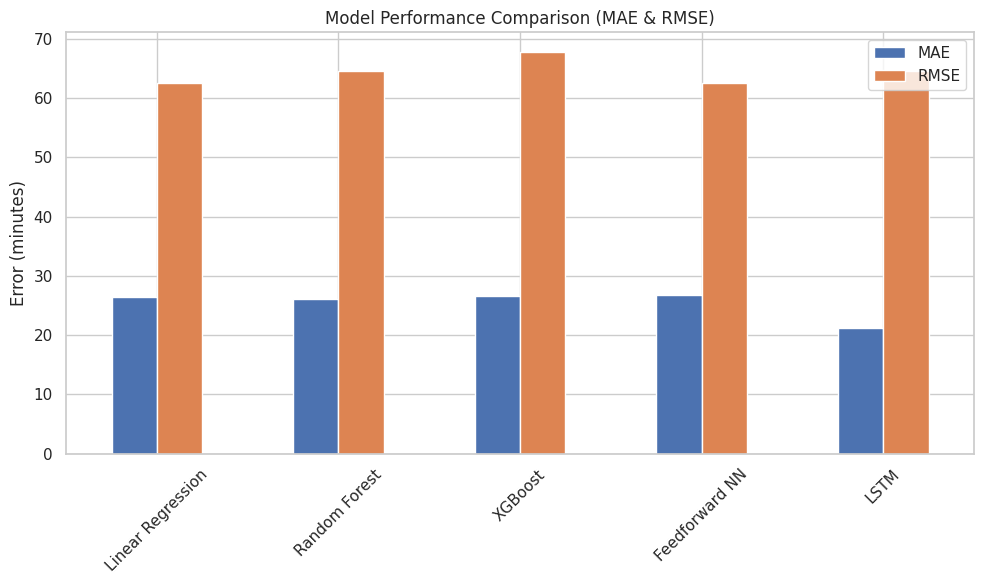

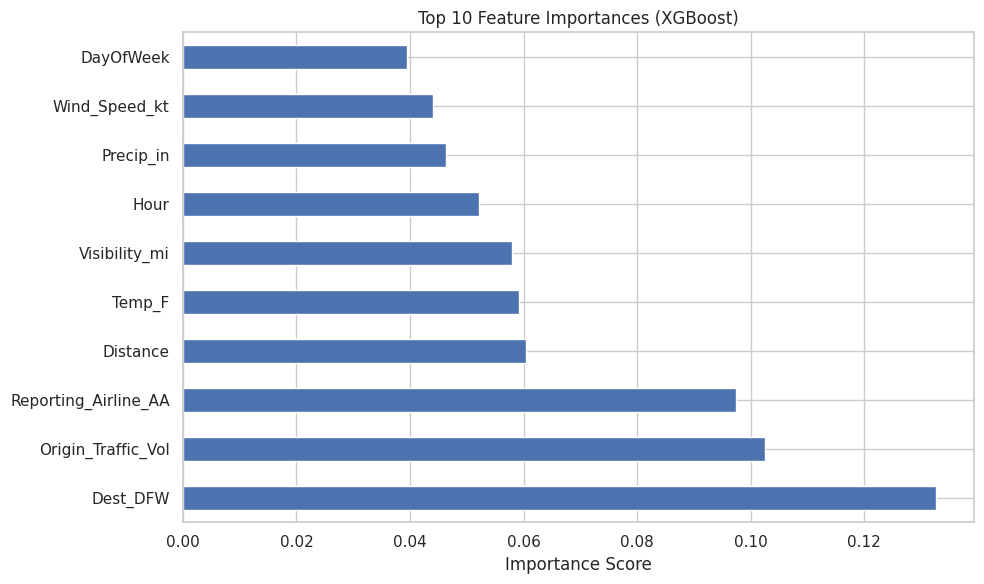

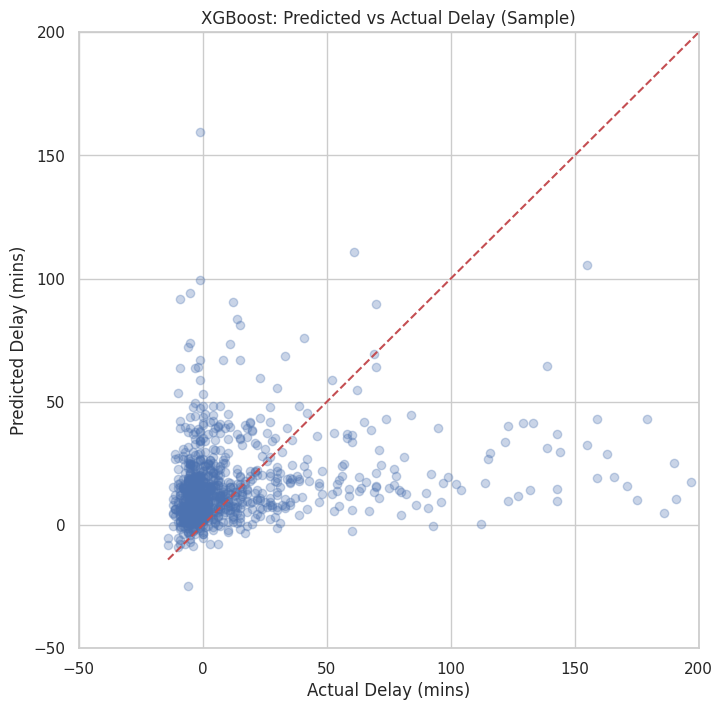

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Input
import time

# --- 4. Model Development & Training ---

# Prepare Data Splits
X = df_modeling.drop(columns=['DepDelay', 'Target_Delay_Class'])
y_reg = df_modeling['DepDelay']
y_cls = df_modeling['Target_Delay_Class']

X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
_, _, y_train_cls, y_test_cls = train_test_split(X, y_cls, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = {}

# 1. Classical ML: Linear Regression
print("Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train_reg)
lr_preds = lr_model.predict(X_test_scaled)
results['Linear Regression'] = {
    'MAE': mean_absolute_error(y_test_reg, lr_preds),
    'RMSE': np.sqrt(mean_squared_error(y_test_reg, lr_preds)),
    'R2': r2_score(y_test_reg, lr_preds)
}

# 2. Classical ML: Random Forest (Subset for speed)
print("Training Random Forest...")
rf_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled[:10000], y_train_reg[:10000]) # Subsample for training time
rf_preds = rf_model.predict(X_test_scaled)
results['Random Forest'] = {
    'MAE': mean_absolute_error(y_test_reg, rf_preds),
    'RMSE': np.sqrt(mean_squared_error(y_test_reg, rf_preds)),
    'R2': r2_score(y_test_reg, rf_preds)
}

# 3. Classical ML: XGBoost
print("Training XGBoost...")
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
xgb_model.fit(X_train_scaled, y_train_reg)
xgb_preds = xgb_model.predict(X_test_scaled)
results['XGBoost'] = {
    'MAE': mean_absolute_error(y_test_reg, xgb_preds),
    'RMSE': np.sqrt(mean_squared_error(y_test_reg, xgb_preds)),
    'R2': r2_score(y_test_reg, xgb_preds)
}

# 4. Deep Learning: Feedforward Neural Network
print("Training Feedforward Neural Network...")
nn_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1) # Regression output
])
nn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
# Train on a subset or full data, epochs kept low for demonstration
nn_history = nn_model.fit(X_train_scaled, y_train_reg, validation_split=0.2, epochs=10, batch_size=256, verbose=0)
nn_preds = nn_model.predict(X_test_scaled).flatten()
results['Feedforward NN'] = {
    'MAE': mean_absolute_error(y_test_reg, nn_preds),
    'RMSE': np.sqrt(mean_squared_error(y_test_reg, nn_preds)),
    'R2': r2_score(y_test_reg, nn_preds)
}
nn_model.save('ffnn_model.h5')

# 5. Deep Learning: LSTM (Treating features as a sequence of 1 timestep for demonstration)
print("Training LSTM...")
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

lstm_model = Sequential([
    Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    LSTM(32, activation='relu'),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.fit(X_train_lstm, y_train_reg, validation_split=0.2, epochs=5, batch_size=256, verbose=0)
lstm_preds = lstm_model.predict(X_test_lstm).flatten()
results['LSTM'] = {
    'MAE': mean_absolute_error(y_test_reg, lstm_preds),
    'RMSE': np.sqrt(mean_squared_error(y_test_reg, lstm_preds)),
    'R2': r2_score(y_test_reg, lstm_preds)
}
lstm_model.save('lstm_model.h5')


# --- 5. Model Evaluation & Visualization ---
print("\nModel Evaluation Results:")
results_df = pd.DataFrame(results).T
print(results_df)

# Plot Model Performance
results_df[['MAE', 'RMSE']].plot(kind='bar', figsize=(10, 6))
plt.title('Model Performance Comparison (MAE & RMSE)')
plt.ylabel('Error (minutes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

# Feature Importance (XGBoost)
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Feature Importances (XGBoost)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# Prediction vs Actual (XGBoost)
plt.figure(figsize=(8, 8))
plt.scatter(y_test_reg[:1000], xgb_preds[:1000], alpha=0.3)
plt.plot([y_test_reg.min(), 200], [y_test_reg.min(), 200], 'r--')
plt.xlabel('Actual Delay (mins)')
plt.ylabel('Predicted Delay (mins)')
plt.title('XGBoost: Predicted vs Actual Delay (Sample)')
plt.xlim(-50, 200)
plt.ylim(-50, 200)
plt.savefig('pred_vs_actual.png')
plt.show()


In [5]:
import requests
import json

# --- 6. Real-Time Prediction System Pipeline ---
print("Simulating Real-Time Prediction Pipeline...")

def get_real_time_weather(airport_code):
    """Fetch real-time METAR data using Aviation Weather API."""
    url = f"https://aviationweather.gov/api/data/metar?ids={airport_code}&format=json"
    try:
        response = requests.get(url)
        data = response.json()
        if data:
            obs = data[0]
            # Map to our feature names
            weather = {
                'Temp_F': obs.get('temp', 0) * 9/5 + 32 if obs.get('temp') is not None else 50.0, # default if missing
                'Wind_Speed_kt': obs.get('wspd', 0),
                'Visibility_mi': 10.0 if obs.get('visib') == '10+' else float(obs.get('visib', 10.0)),
                'Precip_in': 0.0 # Standard METAR might not have hourly precip easily accessible in simple JSON, assume 0 for demo
            }
            return weather
    except Exception as e:
        print(f"Error fetching real-time weather: {e}")
    
    # Fallback default weather
    return {'Temp_F': 50.0, 'Wind_Speed_kt': 5.0, 'Visibility_mi': 10.0, 'Precip_in': 0.0}

def predict_flight_delay(origin, dest, airline, distance, scheduled_time, traffic_vol):
    """Pipeline to predict delay for a new scheduled flight."""
    
    # 1. Get real-time weather for origin
    current_weather = get_real_time_weather(origin)
    print(f"Real-time weather for {origin}: {current_weather}")
    
    # 2. Construct feature vector (must match training feature order exactly)
    # Using the X dataframe from training to get the right columns and structure
    input_data = pd.DataFrame(columns=X.columns)
    input_data.loc[0] = 0 # Initialize with zeros
    
    # Fill known base features
    input_data.loc[0, 'Distance'] = distance
    input_data.loc[0, 'Origin_Traffic_Vol'] = traffic_vol
    input_data.loc[0, 'Month'] = scheduled_time.month
    input_data.loc[0, 'DayOfWeek'] = scheduled_time.weekday()
    input_data.loc[0, 'Hour'] = scheduled_time.hour
    
    # Fill weather features
    for k, v in current_weather.items():
         if k in input_data.columns:
                input_data.loc[0, k] = v
                
    # Fill categorical one-hot features
    airline_col = f'Reporting_Airline_{airline}'
    if airline_col in input_data.columns:
        input_data.loc[0, airline_col] = 1
        
    origin_col = f'Origin_{origin}'
    if origin_col in input_data.columns:
        input_data.loc[0, origin_col] = 1
        
    dest_col = f'Dest_{dest}'
    if dest_col in input_data.columns:
        input_data.loc[0, dest_col] = 1
        
    # 3. Scale input
    input_scaled = scaler.transform(input_data)
    
    # 4. Predict
    pred = xgb_model.predict(input_scaled)[0]
    return pred

# Simulate a flight
test_origin = 'ORD'
test_dest = 'JFK'
test_airline = 'AA'
test_distance = 733.0
test_time = datetime.now() + timedelta(hours=2)
test_traffic = 50 # Assuming 50 scheduled flights this hour at ORD

predicted_delay = predict_flight_delay(
    origin=test_origin, 
    dest=test_dest, 
    airline=test_airline, 
    distance=test_distance, 
    scheduled_time=test_time, 
    traffic_vol=test_traffic
)

print(f"\nPredicted Departure Delay for {test_airline} flight from {test_origin} to {test_dest} scheduled at {test_time.strftime('%Y-%m-%d %H:%00')}:")
print(f"{predicted_delay:.2f} minutes")


Simulating Real-Time Prediction Pipeline...
Error fetching real-time weather: Expecting value: line 1 column 1 (char 0)
Real-time weather for ORD: {'Temp_F': 50.0, 'Wind_Speed_kt': 5.0, 'Visibility_mi': 10.0, 'Precip_in': 0.0}



Predicted Departure Delay for AA flight from ORD to JFK scheduled at 2026-04-09 15:%00:
18.16 minutes


## 7. System Architecture
![Architecture Diagram](architecture.png)

This diagram outlines the full pipeline from data ingestion to real-time inference.
